In [67]:
import time
import numpy as np
import jax
import jax.numpy as jnp

from mGST.visualization import plot_wall_time


def create_xs_and_vs(dim:int):
    key = jax.random.PRNGKey(42)
    key1, key2, key3, key4, key5, key6 = jax.random.split(key, 6)
    # tensor dimensions
    n1 = dim
    n2 = dim//2
    n3 = dim//2

    # Complex matrix and vectors
    x1 = jax.random.normal(key1, shape=(n1//2, n1//2)) + 1j * jax.random.normal(key2, shape=(n1//2, n1//2))
    x2 = jax.random.normal(key3, shape=(n2,)) + 1j * jax.random.normal(key4, shape=(n2,))
    x3 = jax.random.normal(key5, shape=(n3,)) + 1j * jax.random.normal(key6, shape=(n3,))

    # Create tangent vectors for JVP calculations
    v1 = jax.random.normal(key1, shape=(n1//2, n1//2)) + 1j * jax.random.normal(key2, shape=(n1//2, n1//2))
    v2 = jax.random.normal(key3, shape=(n2,)) + 1j * jax.random.normal(key4, shape=(n2,))
    v3 = jax.random.normal(key5, shape=(n3,)) + 1j * jax.random.normal(key6, shape=(n3,))
    
    return (x1, x2, x3), (v1, v2, v3)

def time_jvp_fn_on_x_and_v(fn, x, v, num_runs=50):
    times = []
    for _ in range(num_runs):
        start = time.time()
        jax.block_until_ready(jax.jvp(fn, (x,), (v,)))
        end = time.time()
        times.append(end - start)
    avg_time = np.mean(times)
    std_time = np.std(times)
    return avg_time, std_time

def time_fn_on_x(*args, fn, num_runs=50):
    times = []
    for _ in range(num_runs):
        start = time.time()
        jax.block_until_ready(fn(*args))
        end = time.time()
        times.append(end - start)
    avg_time = np.mean(times)
    std_time = np.std(times)
    return avg_time, std_time

def cost_fn(x1, x2, x3, d):
        matrix = x1
        for _ in range(d):
            matrix = matrix @ x1
        return (x2 @ matrix @ x3).real
    
def timing_performance_vs_dim(dim_values, num_runs=50, depth:int=None):
    if depth is None:
        depth = 5
    
    results = []
    for dim in dim_values:
        print(f"Timing for dim {dim}")
        (x1, x2, x3), (v1, v2, v3) = create_xs_and_vs(dim)
        f_1 = lambda x: cost_fn(x, x2, x3, depth)
        f_2 = lambda x: cost_fn(x1, x, x3, depth)
        f_3 = lambda x: cost_fn(x1, x2, x, depth)
        grad_x1 = jax.grad(f_1)
        grad_x2 = jax.grad(f_2)
        grad_x3 = jax.grad(f_3)

        # Time grad_x1 JVP
        avg_x1, std_x1 = time_jvp_fn_on_x_and_v(grad_x1, x1, v1, num_runs=num_runs)
        # Time grad_x2 JVP
        avg_x2, std_x2 = time_jvp_fn_on_x_and_v(grad_x2, x2, v2, num_runs=num_runs)
        # Time grad_x3 JVP
        avg_x3, std_x3 = time_jvp_fn_on_x_and_v(grad_x3, x3, v3, num_runs=num_runs)

        avg_cost, std_cost = time_fn_on_x(x1, x2, x3, depth, fn=cost_fn, num_runs=num_runs*2)

        results.append({
            'dim': dim,
            'cost_fn': (avg_cost, std_cost),
            'jvp_grad_x1':(avg_x1, std_x1),
            'jvp_grad_x2': (avg_x2, std_x2),
            'jvp_grad_x3': (avg_x3, std_x3),
        })
    return results

def timing_performance_vs_depth(depth_values, num_runs=50, dim:int=None):
    if dim is None:
        dim = int(2*1e2)
        
    (x1, x2, x3), (v1, v2, v3) = create_xs_and_vs(dim)
    
    results = []
    for depth in depth_values:
        print(f"Timing for depth {depth}")
        f_1 = lambda x: cost_fn(x, x2, x3, depth)
        f_2 = lambda x: cost_fn(x1, x, x3, depth)
        f_3 = lambda x: cost_fn(x1, x2, x, depth)

        grad_x1 = jax.grad(f_1)
        grad_x2 = jax.grad(f_2)
        grad_x3 = jax.grad(f_3)

        # Time grad_x1 JVP
        avg_x1, std_x1 = time_jvp_fn_on_x_and_v(grad_x1, x1, v1, num_runs=num_runs)
        # Time grad_x2 JVP
        avg_x2, std_x2 = time_jvp_fn_on_x_and_v(grad_x2, x2, v2, num_runs=num_runs)
        # Time grad_x3 JVP
        avg_x3, std_x3 = time_jvp_fn_on_x_and_v(grad_x3, x3, v3, num_runs=num_runs)

        avg_grad_x1, std_grad_x1 = time_fn_on_x(x1, fn=grad_x1, num_runs=num_runs)
        avg_grad_x2, std_grad_x2 = time_fn_on_x(x2, fn=grad_x2, num_runs=num_runs)
        avg_grad_x3, std_grad_x3 = time_fn_on_x(x3, fn=grad_x3, num_runs=num_runs)

        avg_cost, std_cost = time_fn_on_x(x1, x2, x3, depth, fn=cost_fn, num_runs=num_runs*2)

        results.append({
            'depth': depth,
            'cost_fn': (avg_cost, std_cost),
            'grad_x1': (avg_grad_x1, std_grad_x1),
            'grad_x2': (avg_grad_x2, std_grad_x2),
            'grad_x3': (avg_grad_x3, std_grad_x3),
            'jvp_grad_x1':(avg_x1, std_x1),
            'jvp_grad_x2': (avg_x2, std_x2),
            'jvp_grad_x3': (avg_x3, std_x3),
        })
    return results

In [73]:
# Example usage:
depth_values = [2, 5, 10, 20, 40]
dim = int(2*1e2)
timings = timing_performance_vs_depth(depth_values, dim=dim, num_runs=100)
for res in timings:
    print(res)

Timing for depth 2
Timing for depth 5
Timing for depth 10
Timing for depth 20
Timing for depth 40
{'depth': 2, 'cost_fn': (0.0007282090187072754, 3.6732536286518835e-05), 'grad_x1': (0.001493525505065918, 0.0002618091699744489), 'grad_x2': (0.0010691571235656738, 0.00013397965794770362), 'grad_x3': (0.001109621524810791, 0.00012764236956718178), 'jvp_grad_x1': (0.0024173450469970703, 0.0006385058545601448), 'jvp_grad_x2': (0.0013471460342407227, 0.00044505058795604876), 'jvp_grad_x3': (0.00135695219039917, 0.0002897831713348205)}
{'depth': 5, 'cost_fn': (0.001818690299987793, 0.00013720159613272114), 'grad_x1': (0.002455763816833496, 0.00010465960593173496), 'grad_x2': (0.0013309597969055175, 0.00013900756956569842), 'grad_x3': (0.002114434242248535, 0.004400629609011596), 'jvp_grad_x1': (0.00478841781616211, 0.00014226254085957204), 'jvp_grad_x2': (0.001500861644744873, 0.00011329786972852482), 'jvp_grad_x3': (0.0015393590927124023, 5.754350251460437e-05)}
{'depth': 10, 'cost_fn': (0.

In [37]:
dims_to_test = [int(2**2), int(2**4), int(2**6), int(2**8), int(2**10)]
depth = 5
results_vs_dim = timing_performance_vs_dim(dims_to_test, num_runs=50, depth=depth)
for res in results_vs_dim:
    print(res)

Timing for dim 4
Timing for dim 16
Timing for dim 64
Timing for dim 256
Timing for dim 1024
{'dim': 4, 'cost_fn': (0.0002032470703125, 2.3872819823533727e-05), 'jvp_grad_x1': (0.0023491239547729493, 0.0005587314580834149), 'jvp_grad_x2': (0.0012600755691528321, 0.0001235899549289838), 'jvp_grad_x3': (0.0011670351028442382, 0.00011989087045324436)}
{'dim': 16, 'cost_fn': (0.00022909879684448241, 2.3417683414785574e-05), 'jvp_grad_x1': (0.002241635322570801, 0.00026058072336575987), 'jvp_grad_x2': (0.0013799762725830078, 0.00022858337453280432), 'jvp_grad_x3': (0.0012316274642944335, 0.00017250624469109823)}
{'dim': 64, 'cost_fn': (0.00024361133575439452, 2.0390673674606354e-05), 'jvp_grad_x1': (0.0022223091125488283, 0.00016190907902563324), 'jvp_grad_x2': (0.0012806320190429687, 0.00010390502433655056), 'jvp_grad_x3': (0.001196427345275879, 0.0001568018704903)}
{'dim': 256, 'cost_fn': (0.0008594536781311035, 0.00011591884686268009), 'jvp_grad_x1': (0.0060215950012207035, 0.000513095115

In [56]:
dims_to_test_2 = [200, 300, 400, 500, 600, 700, 800, 900, 1000]
depth = 5
results_vs_dim_2 = timing_performance_vs_dim(dims_to_test_2, num_runs=50, depth=depth)
for res in results_vs_dim_2:
    print(res)

Timing for dim 200
Timing for dim 300
Timing for dim 400
Timing for dim 500
Timing for dim 600
Timing for dim 700
Timing for dim 800
Timing for dim 900
Timing for dim 1000
{'dim': 200, 'cost_fn': (0.0011616754531860352, 0.00010725950372236305), 'jvp_grad_x1': (0.0050079345703125, 0.0008942196376913362), 'jvp_grad_x2': (0.0015951633453369141, 0.0002617171990236099), 'jvp_grad_x3': (0.0017431163787841797, 0.00018019949614930648)}
{'dim': 300, 'cost_fn': (0.0010905337333679199, 0.00012428288967184577), 'jvp_grad_x1': (0.008630967140197754, 0.0008511615483728342), 'jvp_grad_x2': (0.0018974637985229492, 0.0003402935282087942), 'jvp_grad_x3': (0.0016539716720581055, 0.00030383719789105396)}
{'dim': 400, 'cost_fn': (0.0023777198791503904, 0.0032306751157755785), 'jvp_grad_x1': (0.01653594970703125, 0.004000641324602145), 'jvp_grad_x2': (0.002262578010559082, 0.0001590311859265292), 'jvp_grad_x3': (0.0021388721466064453, 0.00010271323465733656)}
{'dim': 500, 'cost_fn': (0.003348388671875, 0.00

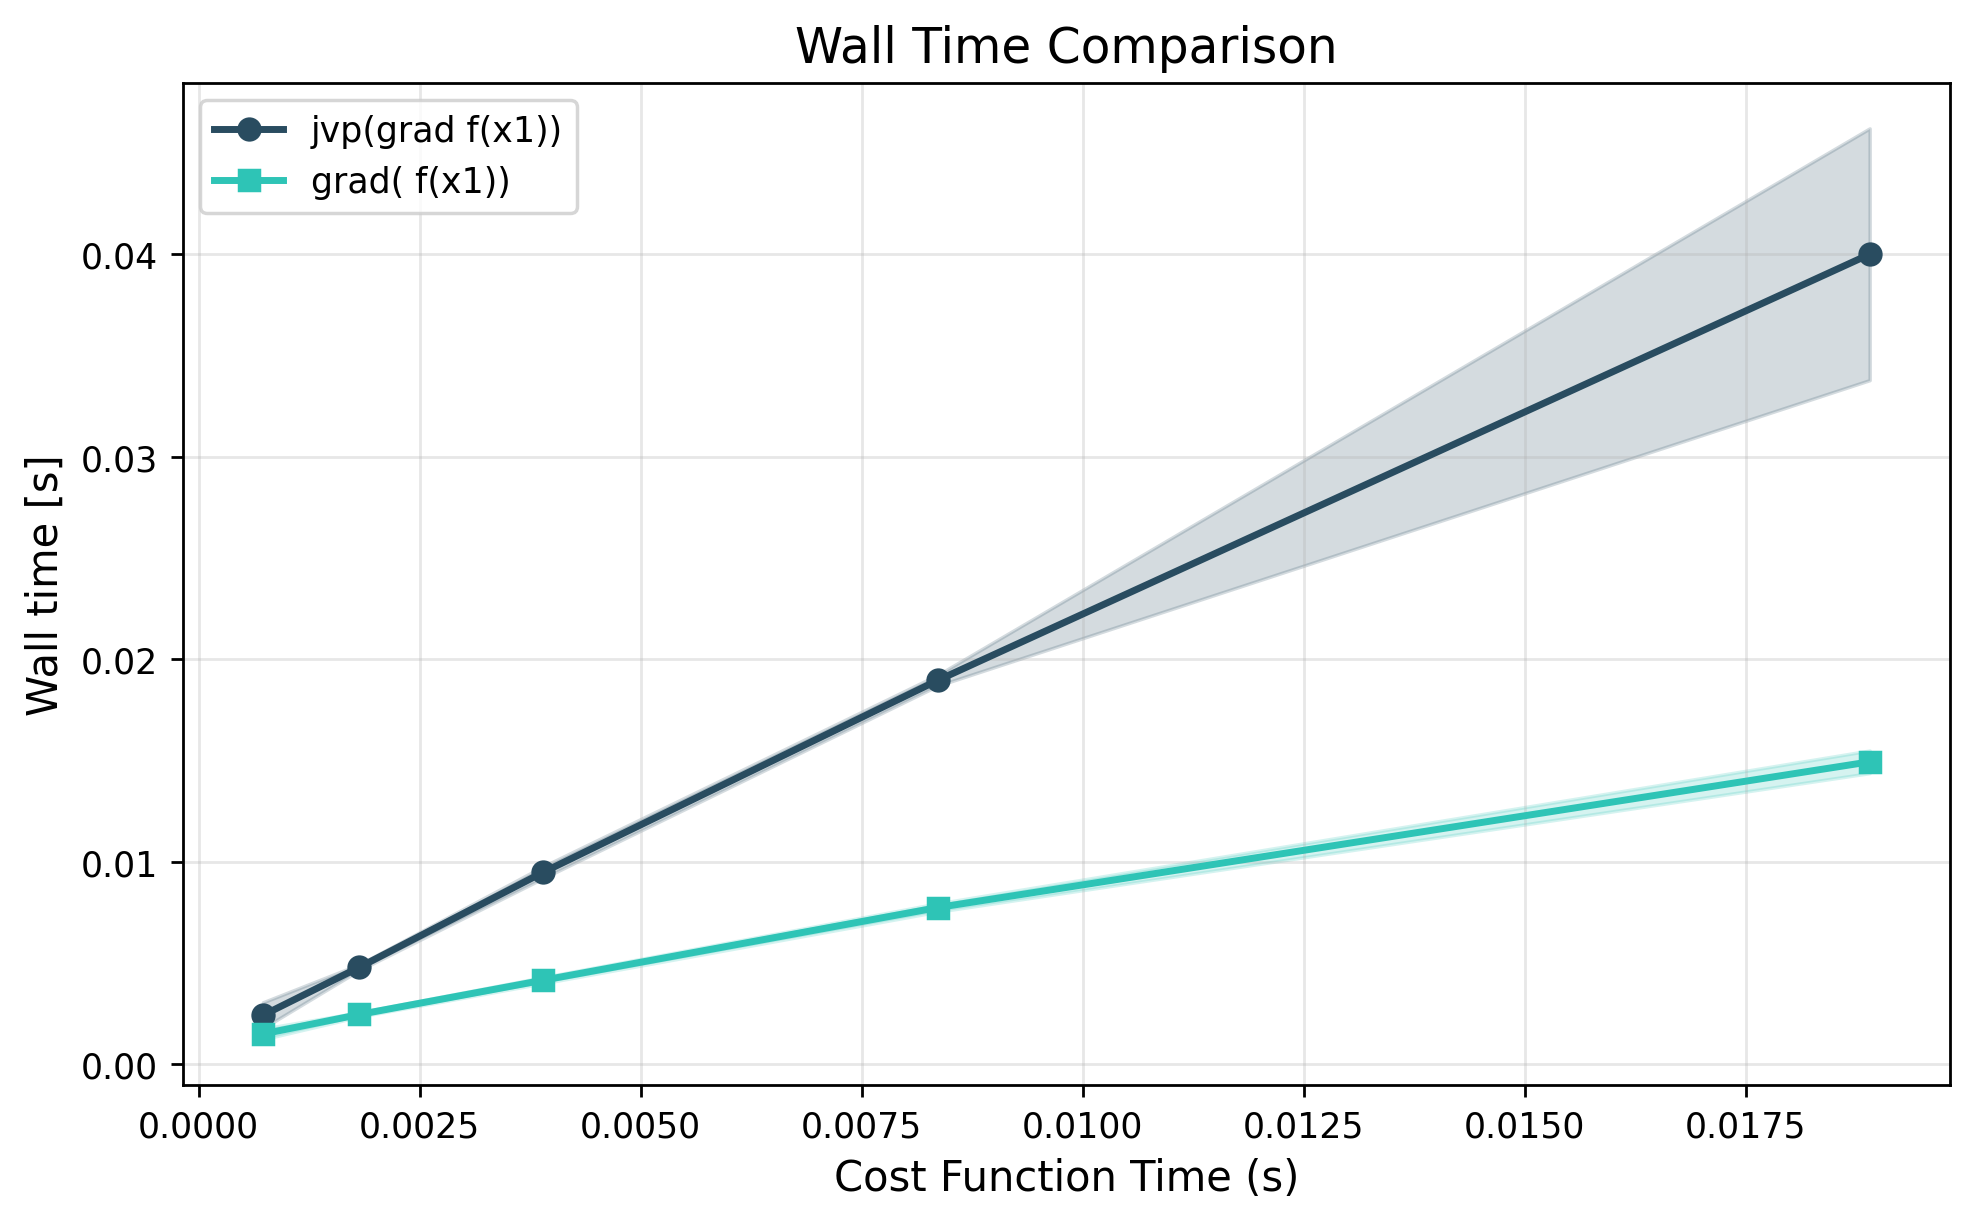

In [76]:
test_times = {
    "jvp(grad f(x1))": [res['jvp_grad_x1'] for res in timings],
    # "jvp(grad f(x2))": [res['jvp_grad_x2'] for res in timings],
    # "jvp(grad f(x3))": [res['jvp_grad_x3'] for res in timings],
    "grad( f(x1))": [res['grad_x1'] for res in timings],
    # "grad( f(x2))": [res['grad_x2'] for res in timings],
    # "grad( f(x3))": [res['grad_x3'] for res in timings],
}
cost_fn_time_list_vs_depth = [res['cost_fn'][0] for res in timings]

plot_wall_time(test_times, cost_fn_time_list_vs_depth, logscale=None, xlabel="Cost Function Time (s)")
# plot_wall_time(test_times, depth_values, logscale=None, xlabel="Depth")

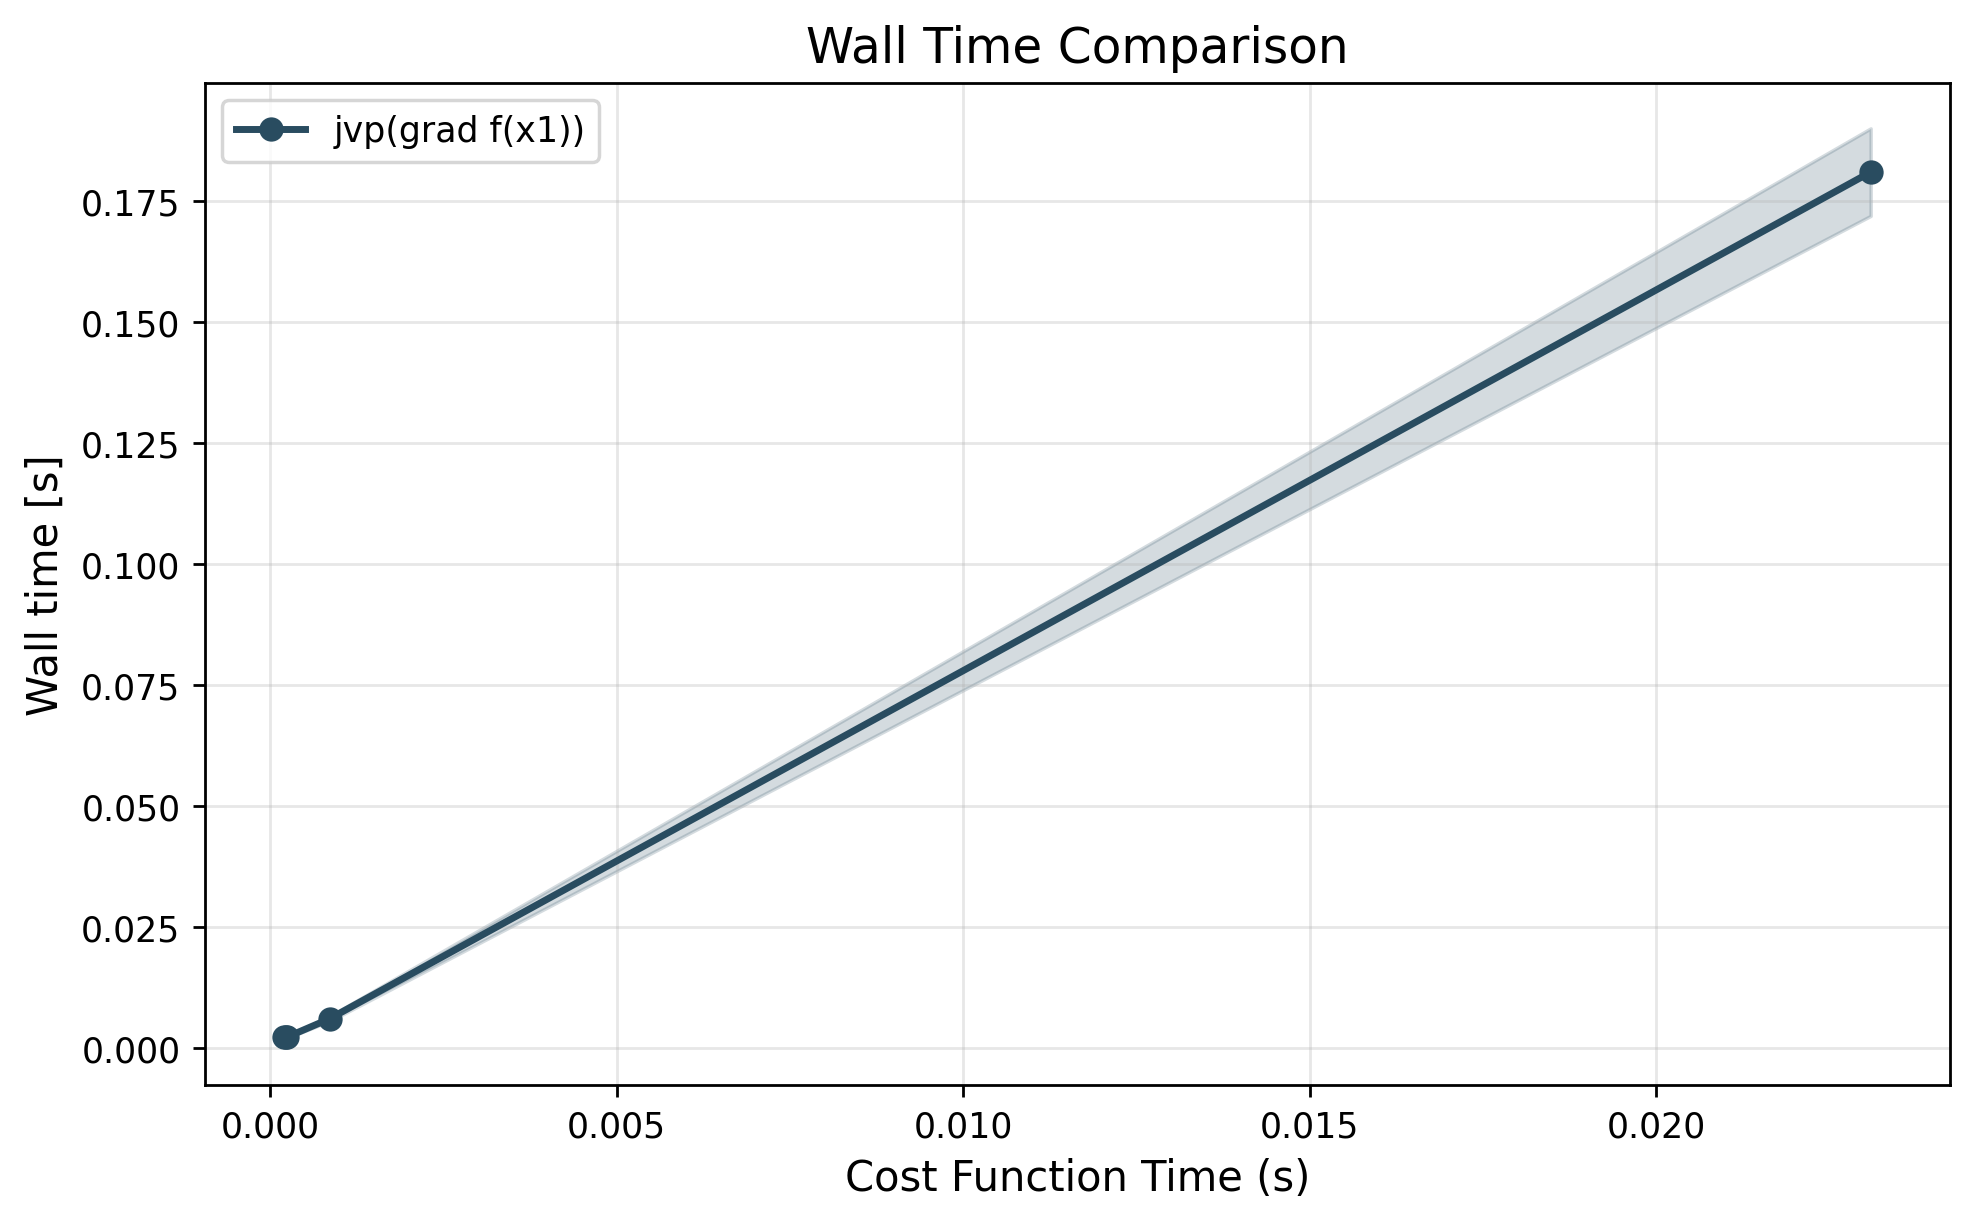

In [63]:
cost_fn_time_list = [res['cost_fn'][0] for res in results_vs_dim]

test_times_vs_dim = {
    "jvp(grad f(x1))": [res['jvp_grad_x1'] for res in results_vs_dim],
    # "jvp(grad f(x2))": [res['jvp_grad_x2'] for res in results_vs_dim],
    # "jvp(grad f(x3))": [res['jvp_grad_x3'] for res in results_vs_dim],
}
# plot_wall_time(test_times_vs_dim, dims_to_test, logscale="xy", xlabel="dimension")
plot_wall_time(test_times_vs_dim, cost_fn_time_list, logscale=None, xlabel="Cost Function Time (s)")

In [49]:
dims_to_test_2

[10, 50, 100, 500, 1000]

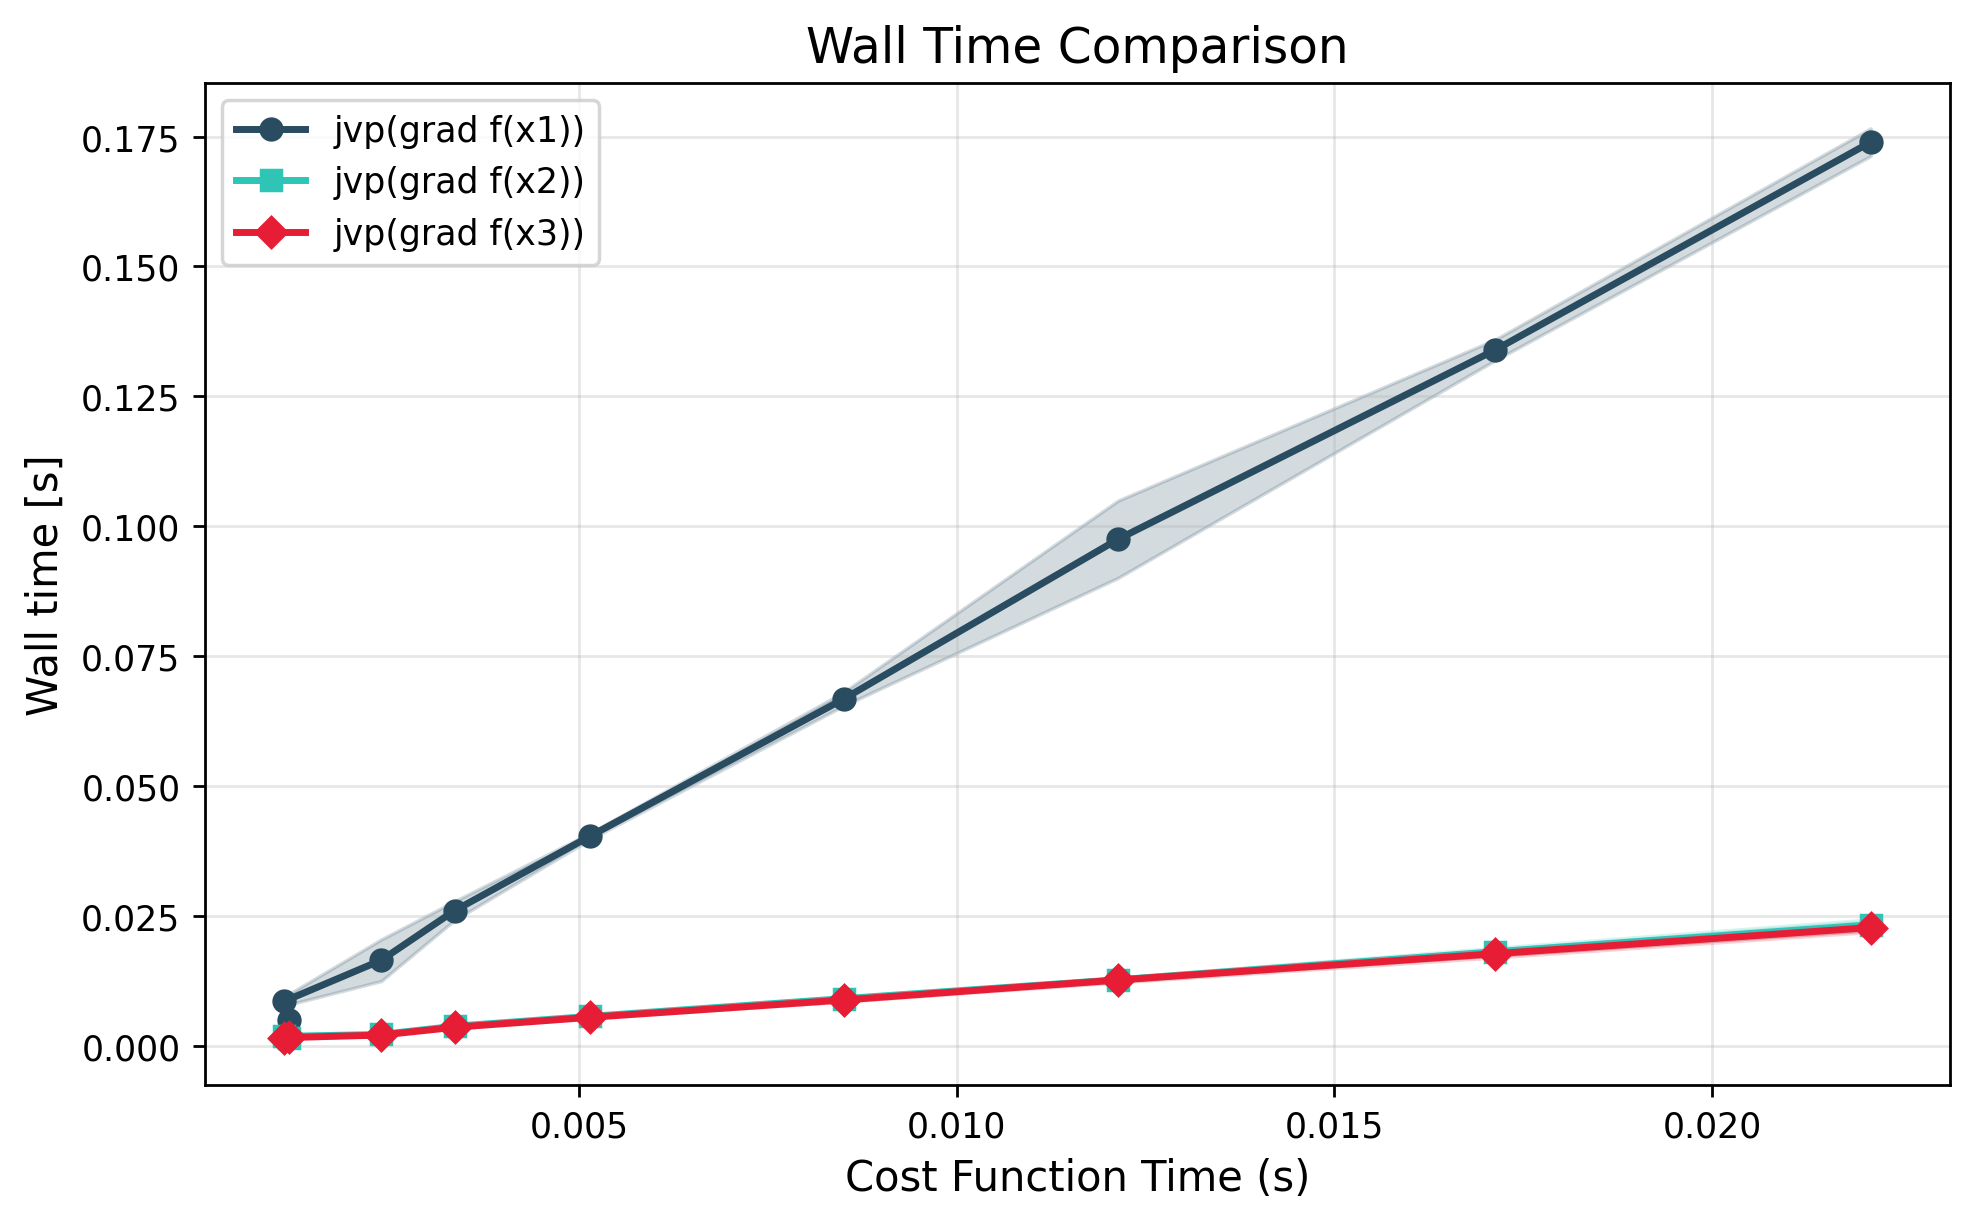

In [60]:
cost_fn_time_list_2 = [res['cost_fn'][0] for res in results_vs_dim_2]

test_times_vs_dim_2 = {
    "jvp(grad f(x1))": [res['jvp_grad_x1'] for res in results_vs_dim_2],
    "jvp(grad f(x2))": [res['jvp_grad_x2'] for res in results_vs_dim_2],
    "jvp(grad f(x3))": [res['jvp_grad_x3'] for res in results_vs_dim_2],
}
# plot_wall_time(test_times_vs_dim_2, dims_to_test_2, logscale=None, xlabel="dimension")
plot_wall_time(test_times_vs_dim_2, cost_fn_time_list_2, logscale=None, xlabel="Cost Function Time (s)")